In [ ]:
!pip install prefixspan
!pip install pymining
!pip install umap-learn

In [ ]:
# Import required libraries
import pandas as pd
from datetime import datetime, timedelta

# Load the dataset
file_path = 'Events08Only.txt'
data = pd.read_csv(file_path, sep='\t', nrows=10000)

# Display a preview of the data
print(data.head())


  RecordID Category         Start Time  End Time  \
0    Guid0  appInit  4/8/2013 00:22:43       NaN   
1    Guid0   resize  4/8/2013 00:22:43       NaN   
2    Guid0   resize  4/8/2013 00:22:43       NaN   
3    Guid0   create  4/8/2013 00:22:44       NaN   
4    Guid0  toolTip  4/8/2013 00:22:49       NaN   

                                          Attributes  
0  p1=histogram; p2=; p3=docId_47DEQpj8HBSa-_TImW...  
1                                     p1=600; p2=301  
2                                     p1=600; p2=301  
3                                                NaN  
4                         p1=dataShape; p2=undefined  


In [ ]:
# Convert 'Start Time' to datetime
data['Start Time'] = pd.to_datetime(data['Start Time'], errors='coerce')

# Check for successful conversion
print(data['Start Time'].head())


0   2013-04-08 00:22:43
1   2013-04-08 00:22:43
2   2013-04-08 00:22:43
3   2013-04-08 00:22:44
4   2013-04-08 00:22:49
Name: Start Time, dtype: datetime64[ns]


In [ ]:
def windowize_events(data, maxspan=10, step=5):
    """
    Perform windowization on event sequences using the 'Category' as event types.

    Parameters:
        data (pd.DataFrame): Input event data with 'RecordID', 'Category', and 'Start Time'.
        maxspan (int): Window size in seconds.
        step (int): Step size in seconds between windows.

    Returns:
        pd.DataFrame: A DataFrame containing windows with their respective events.
    """
    windows = []

    for record_id, group in data.groupby('RecordID'):
        group = group.sort_values('Start Time')
        min_time = group['Start Time'].min()
        max_time = group['Start Time'].max()

        current_start = min_time

        while current_start <= max_time:
            window_end = current_start + timedelta(seconds=maxspan)
            window_data = group[(group['Start Time'] >= current_start) & (group['Start Time'] < window_end)]

            if not window_data.empty:
                windows.append({
                    'RecordID': record_id,
                    'WindowStart': current_start,
                    'WindowEnd': window_end,
                    'Events': list(window_data['Category'])
                })

            current_start += timedelta(seconds=step)

    return pd.DataFrame(windows)


In [ ]:
# Apply the windowization function
windows = windowize_events(data, maxspan=10, step=5)

# Display the first few windows
print(windows.head())


  RecordID         WindowStart           WindowEnd  \
0    Guid0 2013-04-08 00:22:43 2013-04-08 00:22:53   
1    Guid0 2013-04-08 00:22:48 2013-04-08 00:22:58   
2    Guid0 2013-04-08 00:22:53 2013-04-08 00:23:03   
3    Guid0 2013-04-08 00:22:58 2013-04-08 00:23:08   
4    Guid0 2013-04-08 00:23:03 2013-04-08 00:23:13   

                                            Events  
0       [appInit, resize, resize, create, toolTip]  
1                                        [toolTip]  
2                                         [resize]  
3  [resize, toolBarToggle, toolTip, toolBarToggle]  
4          [toolBarToggle, toolTip, toolBarToggle]  


In [ ]:
# Save windows to a CSV file for further use
windows.to_csv('windowized_events.csv', index=False)

# Optional: Display summary statistics
print(windows['Events'].apply(len).describe())


count    5819.000000
mean        2.969926
std         3.376657
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       120.000000
Name: Events, dtype: float64


In [ ]:
from pymining import itemmining, seqmining

def mine_frequent_patterns(windows, minfreq=10):
    """
    Mine frequent patterns using the PrefixSpan algorithm.

    Parameters:
        windows (pd.DataFrame): DataFrame containing windows with events.
        minfreq (int): Minimum frequency threshold for patterns.

    Returns:
        list: List of patterns with their frequencies.
    """
    sequences = windows['Events'].tolist()
    patterns = seqmining.freq_seq_enum(sequences, minfreq)
    return sorted(patterns, key=lambda x: x[1], reverse=True)

# Mine frequent patterns
minfreq = 10
patterns = mine_frequent_patterns(windows, minfreq)

# Display top patterns
print("Top Patterns:")
for pattern, freq in patterns[:10]:
    print(f"Pattern: {pattern}, Frequency: {freq}")


Top Patterns:
Pattern: ('readBoundData',), Frequency: 1674
Pattern: ('toolTip',), Frequency: 1571
Pattern: ('resize',), Frequency: 1445
Pattern: ('resize', 'resize'), Frequency: 939
Pattern: ('treeStats',), Frequency: 788
Pattern: ('appInit',), Frequency: 740
Pattern: ('readBoundData', 'readBoundData'), Frequency: 715
Pattern: ('error',), Frequency: 535
Pattern: ('appInit', 'resize'), Frequency: 479
Pattern: ('bindFromPrompt',), Frequency: 455


In [ ]:
def filter_patterns_by_length(patterns, length):
    """
    Filter patterns by their length.

    Parameters:
        patterns (list): List of (pattern, frequency) tuples.
        length (int): Desired pattern length.

    Returns:
        list: Filtered patterns of the specified length.
    """
    return [p for p in patterns if len(p[0]) == length]

# Get patterns of length 2 and 3
patterns_length_2 = filter_patterns_by_length(patterns, 2)
patterns_length_3 = filter_patterns_by_length(patterns, 3)

# Display the top 5 patterns for each length
print("Top 5 Patterns of Length 2:")
for pattern, freq in patterns_length_2[:5]:
    print(f"Pattern: {pattern}, Frequency: {freq}")

print("Top 5 Patterns of Length 3:")
for pattern, freq in patterns_length_3[:5]:
    print(f"Pattern: {pattern}, Frequency: {freq}")


Top 5 Patterns of Length 2:
Pattern: ('resize', 'resize'), Frequency: 939
Pattern: ('readBoundData', 'readBoundData'), Frequency: 715
Pattern: ('appInit', 'resize'), Frequency: 479
Pattern: ('create', 'resize'), Frequency: 391
Pattern: ('readBoundData', 'treeStats'), Frequency: 373
Top 5 Patterns of Length 3:
Pattern: ('appInit', 'resize', 'resize'), Frequency: 420
Pattern: ('readBoundData', 'readBoundData', 'readBoundData'), Frequency: 354
Pattern: ('create', 'resize', 'resize'), Frequency: 343
Pattern: ('resize', 'resize', 'resize'), Frequency: 306
Pattern: ('create', 'appInit', 'resize'), Frequency: 290


In [ ]:
def generate_temporal_rules(patterns):
    """
    Generate temporal rules from frequent patterns.

    Parameters:
        patterns (list): List of (pattern, frequency) tuples.

    Returns:
        pd.DataFrame: DataFrame containing rules with their measures.
    """
    rules = []
    for pattern, freq in patterns:
        if len(pattern) > 1:
            X = pattern[:-1]
            Y = pattern[-1]
            nX = sum(1 for p, f in patterns if p[:len(X)] == X)
            nY = sum(1 for p, f in patterns if p[-1] == Y)
            nX_Y = freq

            frequency = (nX_Y / len(windows)) * 100
            confidence = nX_Y / nX
            recall = nX_Y / nY
            lift = (nX_Y * len(windows)) / (nX * nY)
            j_measure = confidence * (1 - (nY / len(windows)))

            rules.append({
                'Rule': f"{X} → {Y}",
                'nX': nX,
                'nY': nY,
                'nX_Y': nX_Y,
                'Frequency (%)': frequency,
                'Confidence': confidence,
                'Recall': recall,
                'Lift': lift,
                'J-Measure': j_measure
            })

    return pd.DataFrame(rules)

# Generate temporal rules
rules_df = generate_temporal_rules(patterns)

# Display the top rules
print("Top Rules:")
print(rules_df.sort_values('Lift', ascending=False).head())


Top Rules:
                                             Rule  nX  nY  nX_Y  \
169       ('aboutBox', 'toolTip') → closeAboutBox   4   6    47   
101                 ('aboutBox',) → closeAboutBox   7   6    77   
1048  ('ySlider', 'ySlider', 'ySlider') → ySlider   2   4    13   
124          ('btColor', 'toolTip') → pickedColor   3  14    63   
404       ('toolTip', 'aboutBox') → closeAboutBox   3   6    25   

      Frequency (%)  Confidence     Recall          Lift  J-Measure  
169        0.807699   11.750000   7.833333  11395.541667  11.737885  
101        1.323251   11.000000  12.833333  10668.166667  10.988658  
1048       0.223406    6.500000   3.250000   9455.875000   6.495532  
124        1.082660   21.000000   4.500000   8728.500000  20.949476  
404        0.429627    8.333333   4.166667   8081.944444   8.324741  


In [ ]:
# Filter by specific event types or time periods
interesting_rules = rules_df[(rules_df['Lift'] > 1.5) & (rules_df['Confidence'] > 0.8)]

# Display interesting rules
print("Interesting Rules:")
print(interesting_rules)


Interesting Rules:
                                                   Rule   nX   nY  nX_Y  \
0                                  ('resize',) → resize  126  126   939   
1                    ('readBoundData',) → readBoundData  293  525   715   
2                                 ('appInit',) → resize  276  126   479   
3                        ('appInit', 'resize') → resize   60  126   420   
4                                  ('create',) → resize  338  126   391   
...                                                 ...  ...  ...   ...   
1647  ('aboutBox', 'toolTip', 'closeAboutBox') → too...    2  123    10   
1648  ('load', 'appInit', 'load', 'readBoundData', '...    6  126    10   
1649  ('warning', 'readBoundData', 'warning', 'readB...    2  525    10   
1650  ('load', 'treeStats', 'readBoundData', 'readBo...    2  491    10   
1651  ('appInit', 'create', 'create', 'resize', 'res...    4  491    10   

      Frequency (%)  Confidence    Recall        Lift  J-Measure  
0         16.

In [ ]:
# Generate patterns with a lower frequency threshold to ensure at least 2000 patterns
minfreq = 5
patterns = mine_frequent_patterns(windows, minfreq)

# Transform patterns into temporal rules
rules_df = generate_temporal_rules(patterns)

# Ensure at least 2000 rules
if len(rules_df) < 2000:
    print("Increase the number of patterns by lowering the minfreq threshold.")
else:
    print(f"Generated {len(rules_df)} rules.")


Generated 4838 rules.


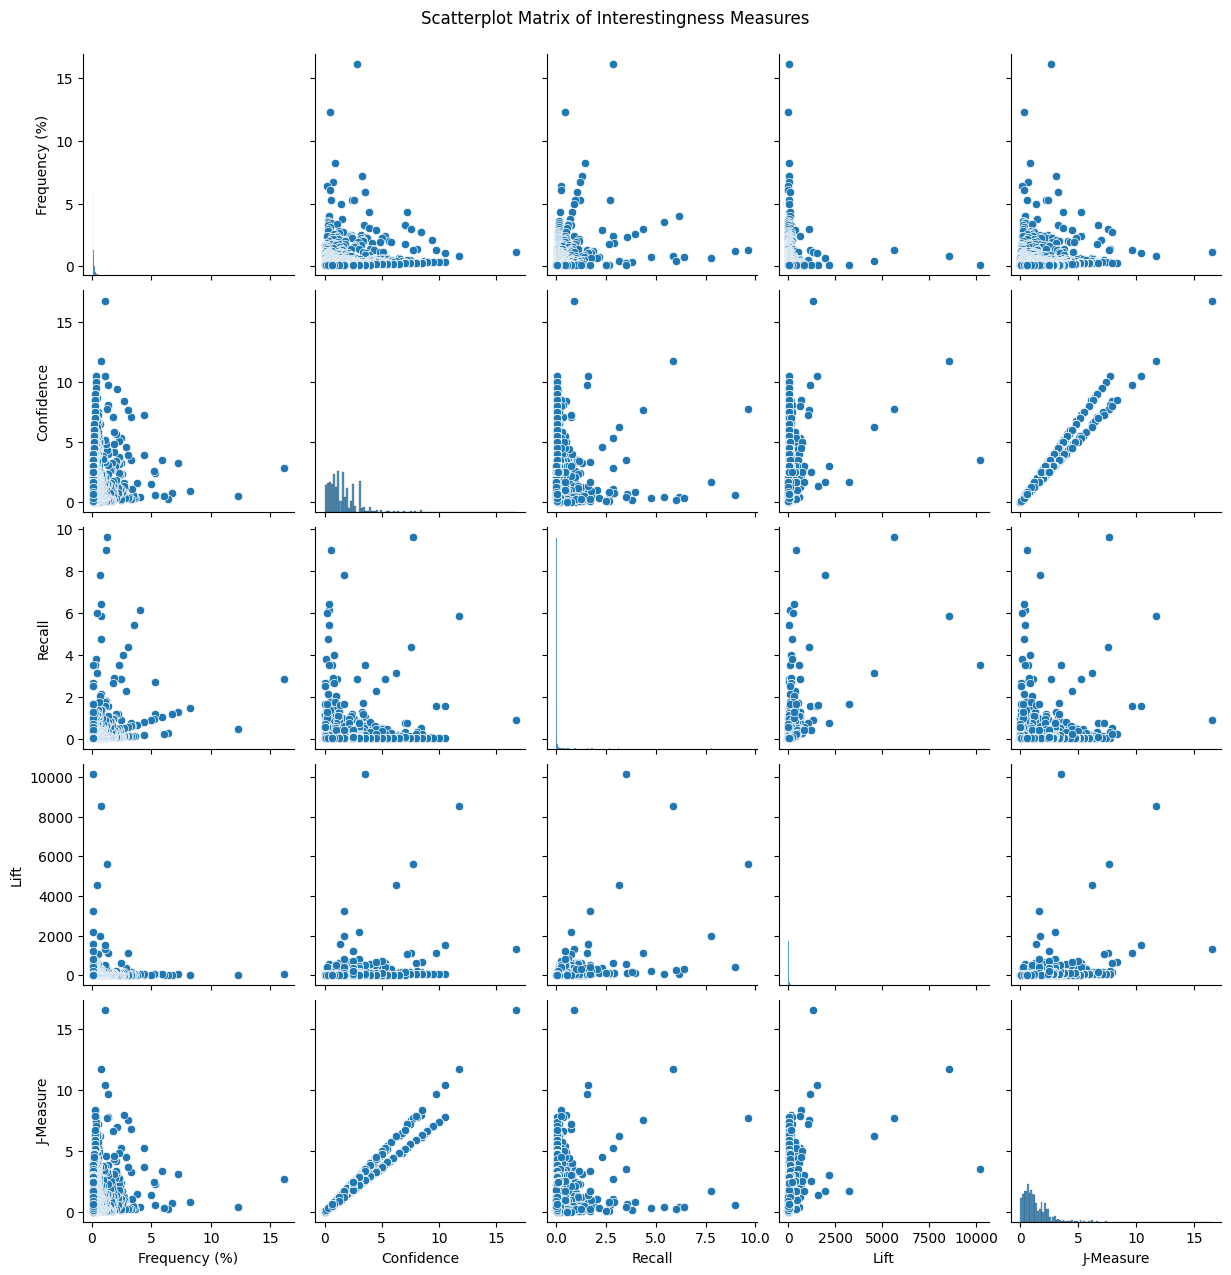

Correlation Matrix:
               Frequency (%)  Confidence    Recall      Lift  J-Measure
Frequency (%)       1.000000    0.054564  0.333345  0.039679   0.077932
Confidence          0.054564    1.000000  0.019641  0.190573   0.979548
Recall              0.333345    0.019641  1.000000  0.497757   0.074033
Lift                0.039679    0.190573  0.497757  1.000000   0.263480
J-Measure           0.077932    0.979548  0.074033  0.263480   1.000000


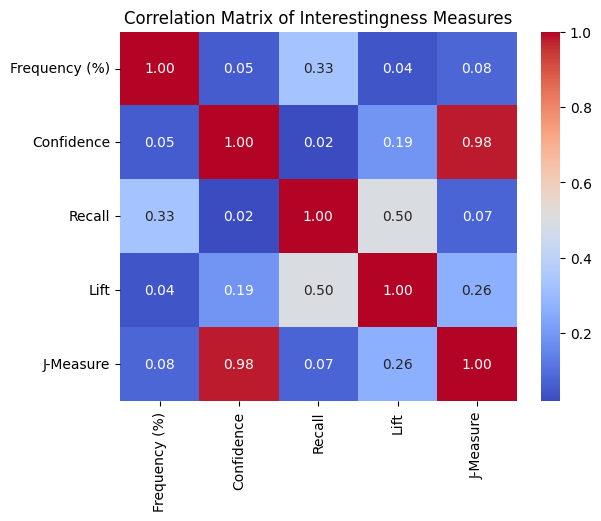

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the interestingness measures for plotting
measures = ['Frequency (%)', 'Confidence', 'Recall', 'Lift', 'J-Measure']

# Scatterplot matrix
sns.pairplot(rules_df[measures])
plt.suptitle("Scatterplot Matrix of Interestingness Measures", y=1.02)
plt.show()

# Compute correlation matrix
correlation_matrix = rules_df[measures].corr()

# Display correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Interestingness Measures")
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


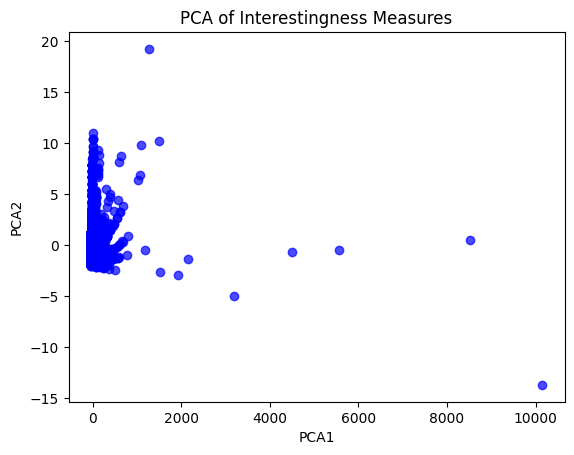

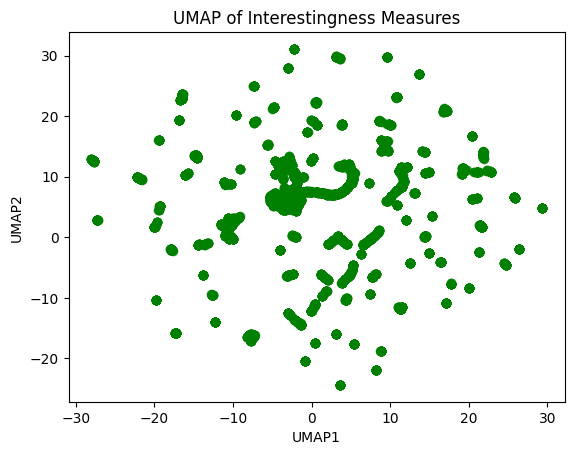

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Prepare the data
X = rules_df[measures]

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
rules_df['PCA1'] = pca_result[:, 0]
rules_df['PCA2'] = pca_result[:, 1]

# UMAP
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
umap_result = umap_reducer.fit_transform(X)
rules_df['UMAP1'] = umap_result[:, 0]
rules_df['UMAP2'] = umap_result[:, 1]

# Scatterplot of PCA
plt.scatter(rules_df['PCA1'], rules_df['PCA2'], alpha=0.7, c='blue')
plt.title("PCA of Interestingness Measures")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

# Scatterplot of UMAP
plt.scatter(rules_df['UMAP1'], rules_df['UMAP2'], alpha=0.7, c='green')
plt.title("UMAP of Interestingness Measures")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()
